<a href="https://colab.research.google.com/github/simge14/StudyZone/blob/master/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kişi 1

In [128]:
# 1. Data Preparation, Cleaning, and Exploratory Data Analysis (EDA)

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Fetch dataset from UCI repository
bank_marketing = fetch_ucirepo(id=222)
df = pd.concat([bank_marketing.data.features, bank_marketing.data.targets], axis=1)
df = df.rename(columns={"day_of_week": "day"})

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        44923 non-null  object
 2   marital    45211 non-null  object
 3   education  43354 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    32191 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   8252 non-null   object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [131]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [132]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["y"].value_counts(normalize=True))

Missing values per column:
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

Target distribution:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [133]:
unknown_cols = ["job", "education", "contact", "poutcome"]
for col in unknown_cols:
    count = (df[col] == "unknown").sum()
    pct = (count / len(df)) * 100
    print(f"{col}: {count} ({pct:.2f}%)")

job: 0 (0.00%)
education: 0 (0.00%)
contact: 0 (0.00%)
poutcome: 0 (0.00%)


In [134]:
df["y"] = df["y"].map({"yes": 1, "no": 0})
df["y"].value_counts()

,count
y,
0,39922
1,5289


In [135]:
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.astype({c: int for c in df_encoded.columns if df_encoded[c].dtype == bool})

print("Shape after one-hot encoding:", df_encoded.shape)

Shape after one-hot encoding: (45211, 39)


In [136]:
from sklearn.preprocessing import StandardScaler

df_encoded["was_contacted_before"] = (df["pdays"] != -1).astype(int)

numeric_cols = ["age", "balance", "day", "duration", "campaign", "previous", "pdays"]
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe()

,age,balance,day,duration,campaign,previous,pdays
count,4.521100e+04,4.521100e+04,4.521100e+04,4.521100e+04,4.521100e+04,4.521100e+04,4.521100e+04
mean,2.112250e-16,1.760208e-17,1.257292e-17,6.035001e-17,3.017500e-17,4.023334e-17,2.011667e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-2.159994e+00,-3.081149e+00,-1.779108e+00,-1.002478e+00,-5.693506e-01,-2.519404e-01,-4.114531e-01
25%,-7.473845e-01,-4.237719e-01,-9.380027e-01,-6.025167e-01,-5.693506e-01,-2.519404e-01,-4.114531e-01
50%,-1.823406e-01,-3.002800e-01,2.326031e-02,-3.035165e-01,-2.465603e-01,-2.519404e-01,-4.114531e-01
75%,6.652252e-01,2.158743e-02,6.240497e-01,2.362370e-01,7.622994e-02,-2.519404e-01,-4.114531e-01
max,5.091402e+00,3.309478e+01,1.825628e+00,1.809470e+01,1.944365e+01,1.191360e+02,8.297431e+00


In [137]:
features_A = [c for c in df_encoded.columns if c != "y"]
features_B = [c for c in df_encoded.columns if c not in ("y", "duration")]

print("Scenario A feature count:", len(features_A))
print("Scenario B feature count:", len(features_B))

Scenario A feature count: 39
Scenario B feature count: 38


In [138]:
from sklearn.model_selection import train_test_split

X_A = df_encoded[features_A]
X_B = df_encoded[features_B]
y = df_encoded["y"]

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(X_A, y, test_size=0.2, random_state=42, stratify=y)
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

print("Train set shape:", X_B_train.shape, "Test set shape:", X_B_test.shape)
print("Train positive rate:", y_B_train.mean())
print("Test positive rate:", y_B_test.mean())

Train set shape: (36168, 38) Test set shape: (9043, 38)
Train positive rate: 0.11698186241981863
Test positive rate: 0.11699657193409267


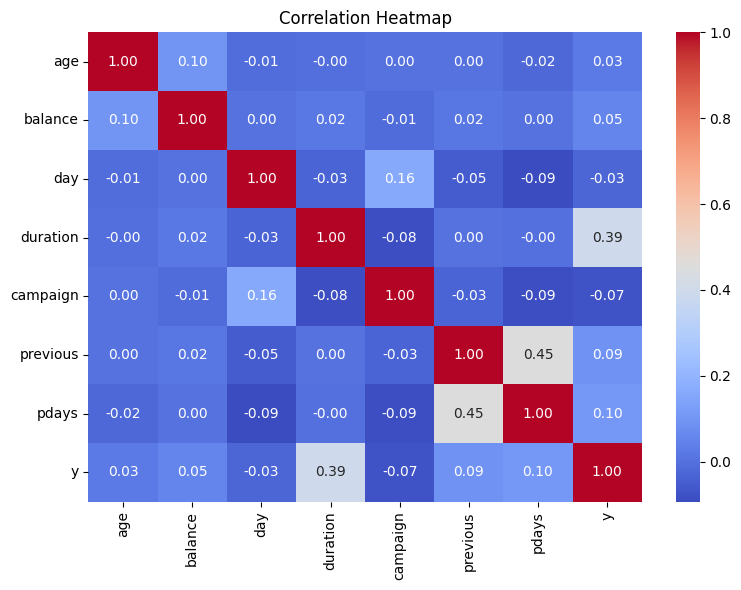

In [139]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded[numeric_cols + ["y"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

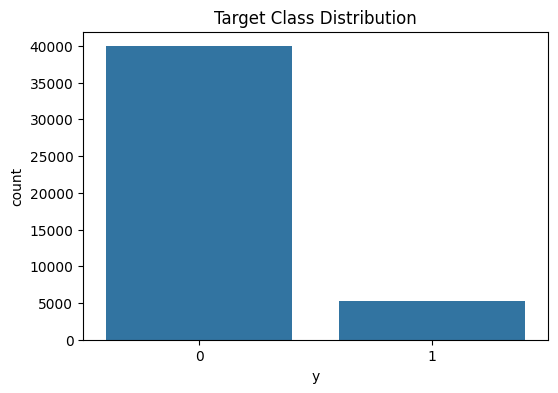

In [140]:
plt.figure(figsize=(6, 4))
sns.countplot(x="y", data=df)
plt.title("Target Class Distribution")
plt.show()

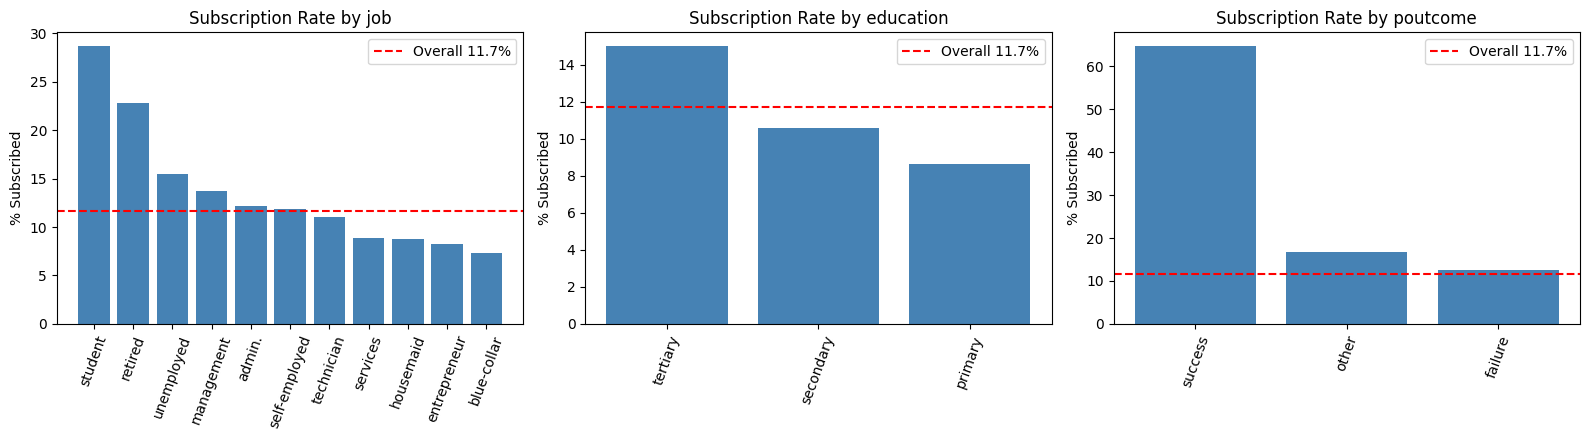

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ["job", "education", "poutcome"]):
    rate = df.groupby(col)["y"].mean().sort_values(ascending=False) * 100
    ax.bar(rate.index.astype(str), rate.values, color="steelblue")
    ax.axhline(df["y"].mean() * 100, color="red", linestyle="--", label="Overall 11.7%")
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_ylabel("% Subscribed")
    ax.tick_params(axis="x", rotation=70)
    ax.legend()

plt.tight_layout()
plt.show()



```

```

# Kişi 2


In [142]:
# 2. Individual Models, PCA, and Customer Segmentation (K-Means)

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Using the Scenario B train/test sets created in step 1
X_train = X_B_train
X_test = X_B_test
y_train = y_B_train
y_test = y_B_test

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train positive rate:", round(y_train.mean(), 3))

Train shape: (36168, 38) | Test shape: (9043, 38)
Train positive rate: 0.117


In [144]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train, y_train)

print(f"Logistic Regression Train Accuracy: {log_model.score(X_train, y_train):.3f}")

Logistic Regression Train Accuracy: 0.763


In [145]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
tree_model.fit(X_train, y_train)

print(f"Tree Depth: {tree_model.get_depth()} | Leaves: {tree_model.get_n_leaves()}")
print(f"Decision Tree Train Accuracy: {tree_model.score(X_train, y_train):.3f}")

Tree Depth: 47 | Leaves: 6268
Decision Tree Train Accuracy: 1.000


In [146]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("KNN model training complete.")

KNN model training complete.


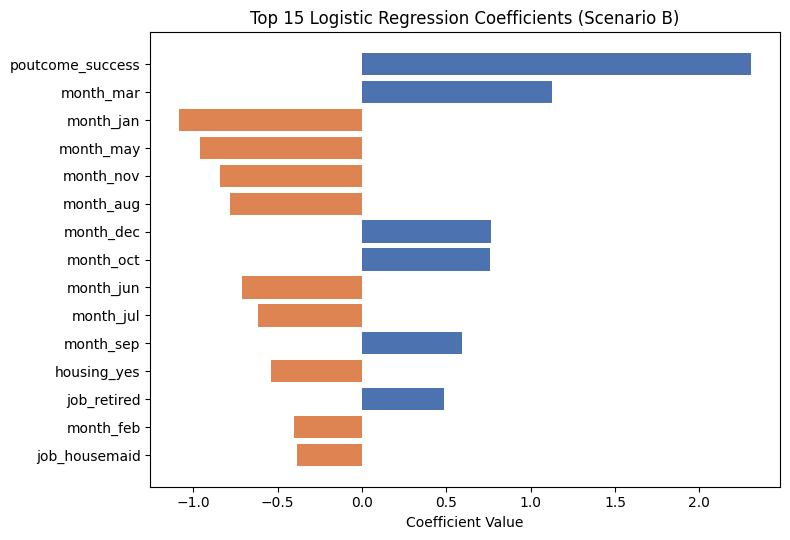

In [147]:
coefs = pd.Series(log_model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 5.5))
colors = ["#DD8452" if v < 0 else "#4C72B0" for v in coefs.values]
plt.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
plt.title("Top 15 Logistic Regression Coefficients (Scenario B)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

Explained variance ratio: [0.1814 0.1287]
Total explained variance: 0.3101


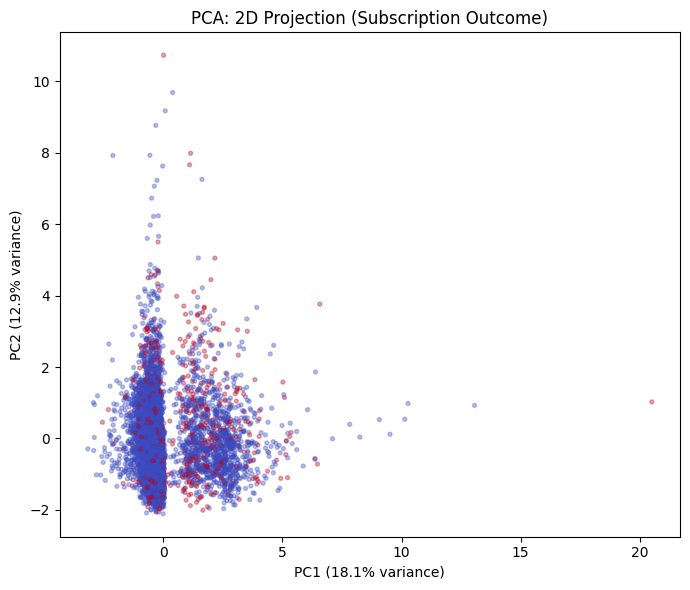

In [148]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(7, 6))
# Plotting a random sample of 8000 points to keep the scatter clean
idx = np.random.RandomState(42).choice(len(X_pca), 8000, replace=False)
plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=y_train.iloc[idx], cmap="coolwarm", alpha=0.35, s=8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA: 2D Projection (Subscription Outcome)")
plt.tight_layout()
plt.show()

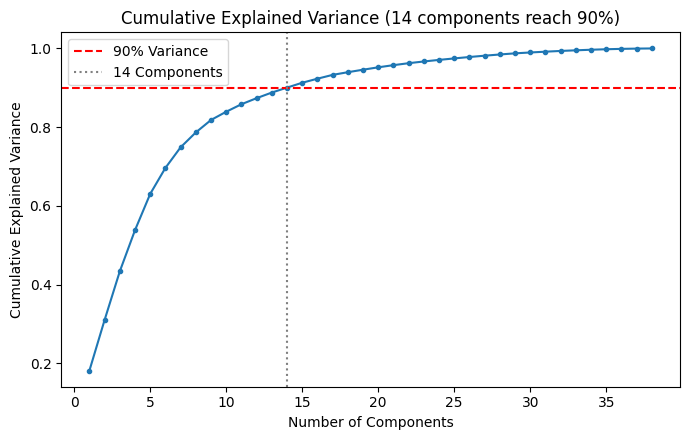

14 components needed to explain 90% variance out of 38


In [149]:
pca_full = PCA(random_state=42).fit(X_train)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum_variance >= 0.90) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker="o", ms=3)
plt.axhline(0.90, color="red", linestyle="--", label="90% Variance")
plt.axvline(n90, color="grey", linestyle=":", label=f"{n90} Components")
plt.title(f"Cumulative Explained Variance ({n90} components reach 90%)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{n90} components needed to explain 90% variance out of {X_train.shape[1]}")

k=2: Inertia = 287,808 | Silhouette = 0.250
k=3: Inertia = 263,699 | Silhouette = 0.116
k=4: Inertia = 243,506 | Silhouette = 0.140
k=5: Inertia = 226,398 | Silhouette = 0.137
k=6: Inertia = 211,104 | Silhouette = 0.122


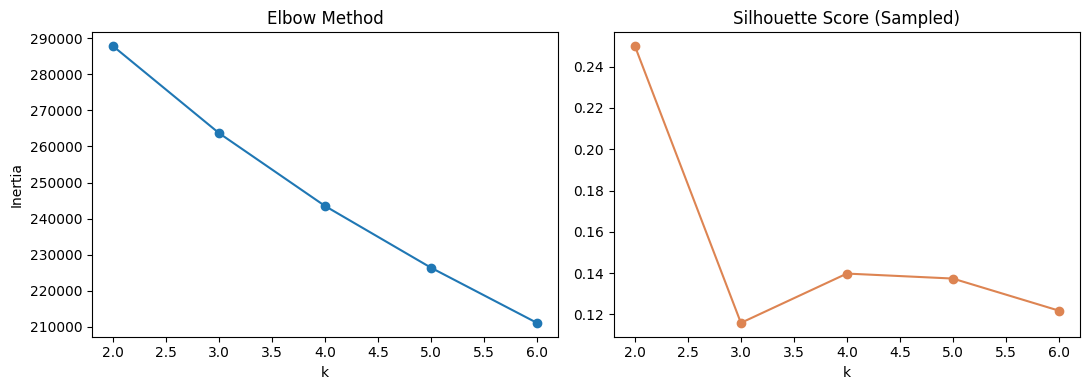

In [150]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 5000-row sample for fast silhouette calculation
sample_idx = np.random.RandomState(42).choice(len(X_train), 5000, replace=False)

inertias, sils = [], []
ks = [2, 3, 4, 5, 6]

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
    inertias.append(km.inertia_)
    score = silhouette_score(X_train.iloc[sample_idx], km.labels_[sample_idx])
    sils.append(score)
    print(f"k={k}: Inertia = {km.inertia_:,.0f} | Silhouette = {score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(ks, sils, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score (Sampled)")
axes[1].set_xlabel("k")

plt.tight_layout()
plt.show()

         n_clients  subscription_rate
cluster                              
0             5401              20.03
1            17866              10.21
2             1410               4.75
3            11491              10.95

Cluster Means:
          age  balance  campaign  previous  was_contacted_before
cluster                                                         
0       -0.14     0.01     -0.21      1.26                  1.00
1       -0.65    -0.14     -0.16     -0.23                  0.03
2       -0.05    -0.07      3.74     -0.24                  0.00
3        1.07     0.23     -0.11     -0.20                  0.06


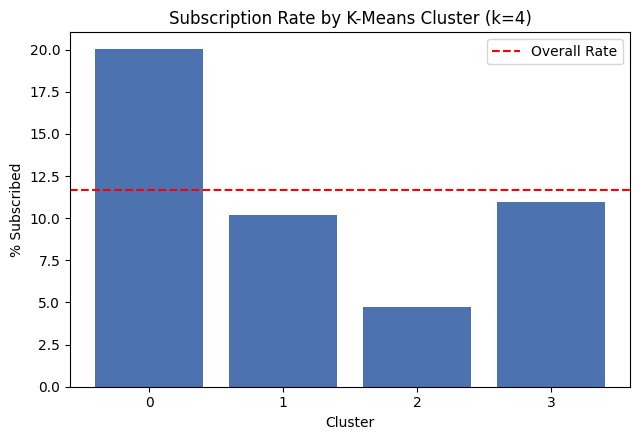

In [151]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train)

cluster_df = pd.DataFrame({"cluster": clusters, "subscribed": y_train.values})
profile = cluster_df.groupby("cluster")["subscribed"].agg(["size", "mean"])
profile.columns = ["n_clients", "subscription_rate"]
profile["subscription_rate"] = (profile["subscription_rate"] * 100).round(2)
print(profile)

# Centroid feature means
centroid_features = ["age", "balance", "campaign", "previous", "was_contacted_before"]
prof2 = X_train.assign(cluster=clusters).groupby("cluster")[centroid_features].mean().round(2)
print("\nCluster Means:")
print(prof2)

# Plotting cluster subscription rates
plt.figure(figsize=(6.5, 4.5))
plt.bar(profile.index.astype(str), profile["subscription_rate"], color="#4C72B0")
plt.axhline(y_train.mean() * 100, color="red", linestyle="--", label="Overall Rate")
plt.title("Subscription Rate by K-Means Cluster (k=4)")
plt.xlabel("Cluster")
plt.ylabel("% Subscribed")
plt.legend()
plt.tight_layout()
plt.show()

# Kişi 3


In [87]:
# 3. Ensemble Models, Cross-Validation, and Hyperparameter Tuning

In [88]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# 2. Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# 3. Soft-Voting Ensemble (Logistic Regression, Decision Tree, Random Forest)
voting_model = VotingClassifier(
    estimators=[("lr", log_model), ("dt", tree_model), ("rf", rf_model)],
    voting="soft"
)
voting_model.fit(X_train, y_train)

print("Ensemble models trained successfully.")

Ensemble models trained successfully.


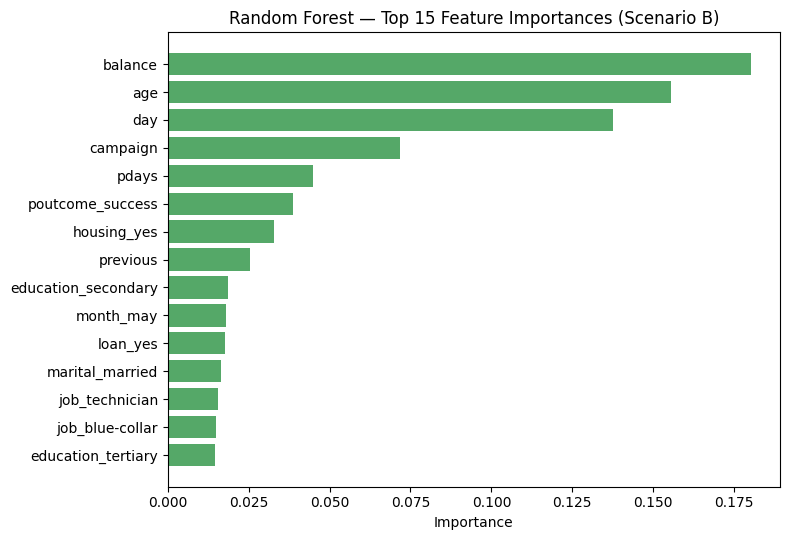

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5.5))
plt.barh(importances.index[::-1], importances.values[::-1], color="#55A868")
plt.title("Random Forest — Top 15 Feature Importances (Scenario B)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [90]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogisticRegression": log_model,
    "DecisionTree": tree_model,
    "KNN": knn_model,
    "RandomForest": rf_model,
    "GradientBoosting": gb_model,
    "VotingEnsemble": voting_model
}

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_results.append({"Model": name, "F1_mean": scores.mean(), "F1_std": scores.std()})
    print(f"{name:20s} F1 mean = {scores.mean():.3f} | std = {scores.std():.3f}")

cv_df = pd.DataFrame(cv_results).sort_values("F1_mean", ascending=False)
cv_df

LogisticRegression   F1 mean = 0.366 | std = 0.005
DecisionTree         F1 mean = 0.278 | std = 0.012
KNN                  F1 mean = 0.273 | std = 0.023
RandomForest         F1 mean = 0.297 | std = 0.015
GradientBoosting     F1 mean = 0.309 | std = 0.020
VotingEnsemble       F1 mean = 0.331 | std = 0.013


,Model,F1_mean,F1_std
0,LogisticRegression,0.365501,0.004929
5,VotingEnsemble,0.330718,0.013398
4,GradientBoosting,0.309351,0.019969
3,RandomForest,0.296810,0.014791
1,DecisionTree,0.278151,0.012401
2,KNN,0.273274,0.023475


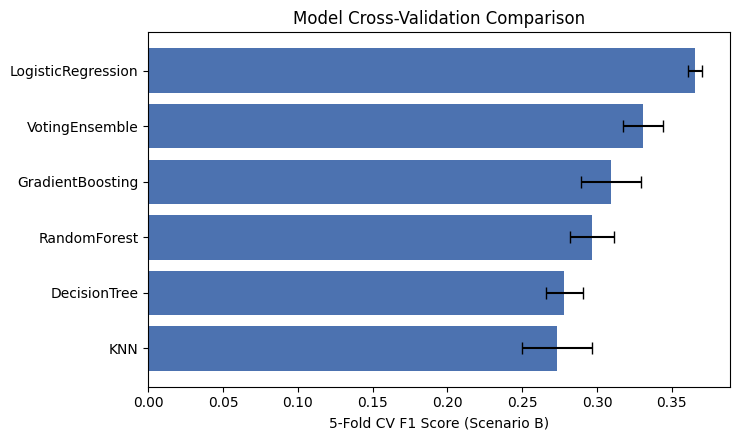

In [91]:
plt.figure(figsize=(7.5, 4.5))
plt.barh(cv_df["Model"][::-1], cv_df["F1_mean"][::-1], xerr=cv_df["F1_std"][::-1], color="#4C72B0", capsize=4)
plt.xlabel("5-Fold CV F1 Score (Scenario B)")
plt.title("Model Cross-Validation Comparison")
plt.tight_layout()
plt.show()

In [92]:
from sklearn.model_selection import GridSearchCV

# 1. Decision Tree Tuning
param_grid_tree = {"max_depth": [5, 10, 20], "min_samples_leaf": [1, 10, 20]}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight="balanced"),
                         param_grid_tree, cv=3, scoring="f1")
grid_tree.fit(X_train, y_train)
print("Best DecisionTree:", grid_tree.best_params_, f"| F1: {grid_tree.best_score_:.3f}")

# 2. KNN Tuning
param_grid_knn = {"n_neighbors": [5, 9, 15, 25]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring="f1")
grid_knn.fit(X_train, y_train)
print("Best KNN:", grid_knn.best_params_, f"| F1: {grid_knn.best_score_:.3f}")

# 3. Random Forest Tuning
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                       param_grid_rf, cv=3, scoring="f1")
grid_rf.fit(X_train, y_train)
print("Best RandomForest:", grid_rf.best_params_, f"| F1: {grid_rf.best_score_:.3f}")

Best DecisionTree: {'max_depth': 10, 'min_samples_leaf': 20} | F1: 0.382
Best KNN: {'n_neighbors': 5} | F1: 0.266
Best RandomForest: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100} | F1: 0.440


In [93]:
# Save best estimators for final evaluation
tree_tuned = grid_tree.best_estimator_
knn_tuned = grid_knn.best_estimator_
rf_tuned = grid_rf.best_estimator_

tuning_summary = pd.DataFrame([
    {"Model": "DecisionTree", "Best Params": str(grid_tree.best_params_), "Best CV F1": round(grid_tree.best_score_, 4)},
    {"Model": "KNN", "Best Params": str(grid_knn.best_params_), "Best CV F1": round(grid_knn.best_score_, 4)},
    {"Model": "RandomForest", "Best Params": str(grid_rf.best_params_), "Best CV F1": round(grid_rf.best_score_, 4)}
])

tuning_summary

,Model,Best Params,Best CV F1
0,DecisionTree,"{'max_depth': 10, 'min_samples_leaf': 20}",0.3822
1,KNN,{'n_neighbors': 5},0.2658
2,RandomForest,"{'max_depth': 20, 'min_samples_split': 10, 'n_...",0.4402


# Kişi 4


In [94]:
# 4. Model Evaluation, Threshold Tuning, Scenario A vs. B, and Business Impact Analysis

In [95]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)

# Dictionary of all trained models (Scenario B)
models_all = {
    "LogisticRegression": log_model,
    "DecisionTree": tree_model,
    "KNN": knn_model,
    "DecisionTree_tuned": tree_tuned,
    "KNN_tuned": knn_tuned,
    "RandomForest": rf_model,
    "RandomForest_tuned": rf_tuned,
    "GradientBoosting": gb_model,
    "VotingEnsemble": voting_model
}

proba_store = {}
results = []

for name, model in models_all.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    proba_store[name] = proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba)
    })

# Baseline model (always predicting 'no')
results.append({
    "Model": "Baseline (always 'no')",
    "Accuracy": accuracy_score(y_test, np.zeros_like(y_test)),
    "Precision": 0.0,
    "Recall": 0.0,
    "F1": 0.0,
    "ROC-AUC": 0.5,
    "PR-AUC": y_test.mean()
})

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,RandomForest_tuned,0.880,0.483,0.424,0.452,0.785,0.432
1,DecisionTree_tuned,0.786,0.288,0.560,0.380,0.744,0.386
2,LogisticRegression,0.762,0.268,0.597,0.370,0.752,0.393
3,VotingEnsemble,0.862,0.389,0.315,0.348,0.761,0.373
4,GradientBoosting,0.894,0.657,0.204,0.311,0.777,0.434
5,RandomForest,0.895,0.664,0.199,0.307,0.778,0.424
6,DecisionTree,0.836,0.293,0.287,0.290,0.598,0.168
7,KNN,0.886,0.535,0.182,0.272,0.693,0.280
8,KNN_tuned,0.886,0.535,0.182,0.272,0.693,0.280
9,Baseline (always 'no'),0.883,0.000,0.000,0.000,0.500,0.117


In [96]:
thr_rows = []

for name, proba in proba_store.items():
    prec, rec, thr = precision_recall_curve(y_test, proba)
    f1s = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
    best_idx = int(np.argmax(f1s[:-1]))

    thr_rows.append({
        "Model": name,
        "Best Threshold": round(thr[best_idx], 3),
        "F1 @ Best": round(f1s[best_idx], 3),
        "Precision @ Best": round(prec[best_idx], 3),
        "Recall @ Best": round(rec[best_idx], 3),
        "F1 @ 0.5": round(f1_score(y_test, (proba >= 0.5).astype(int)), 3)
    })

thr_df = pd.DataFrame(thr_rows).sort_values("F1 @ Best", ascending=False).reset_index(drop=True)
thr_df

,Model,Best Threshold,F1 @ Best,Precision @ Best,Recall @ Best,F1 @ 0.5
0,GradientBoosting,0.174,0.475,0.464,0.487,0.311
1,RandomForest_tuned,0.451,0.468,0.443,0.496,0.452
2,RandomForest,0.230,0.460,0.429,0.495,0.307
3,DecisionTree_tuned,0.578,0.438,0.427,0.450,0.380
4,LogisticRegression,0.660,0.431,0.472,0.397,0.370
5,VotingEnsemble,0.286,0.414,0.343,0.522,0.348
6,KNN,0.400,0.372,0.385,0.359,0.272
7,KNN_tuned,0.400,0.372,0.385,0.359,0.272
8,DecisionTree,1.000,0.290,0.293,0.287,0.290


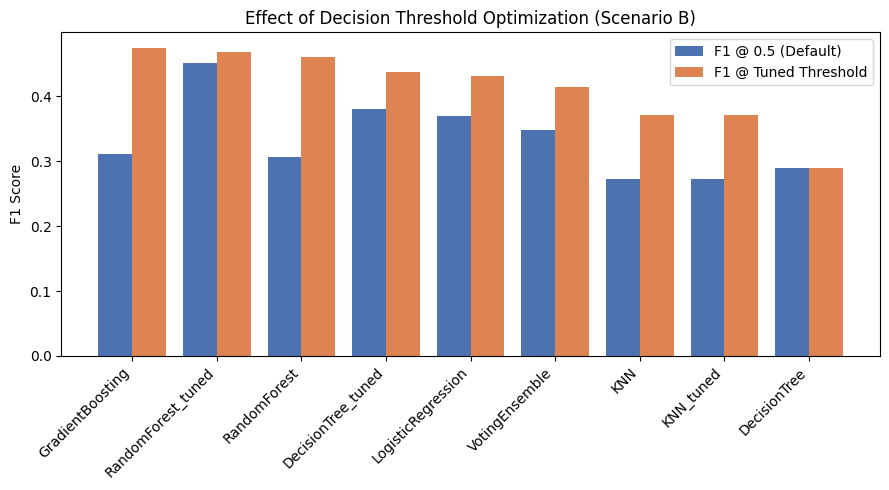

In [97]:
plt.figure(figsize=(9, 5))
x = np.arange(len(thr_df))

plt.bar(x - 0.2, thr_df["F1 @ 0.5"], width=0.4, label="F1 @ 0.5 (Default)", color="#4C72B0")
plt.bar(x + 0.2, thr_df["F1 @ Best"], width=0.4, label="F1 @ Tuned Threshold", color="#DD8452")

plt.xticks(x, thr_df["Model"], rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Effect of Decision Threshold Optimization (Scenario B)")
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
# Train key models on Scenario A (duration included)
scenarioA_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

rows_A = []
for name, model in scenarioA_models.items():
    model.fit(X_A_train, y_A_train)
    pred_A = model.predict(X_A_test)
    proba_A = model.predict_proba(X_A_test)[:, 1]

    rows_A.append({
        "Model": name,
        "F1_A": f1_score(y_A_test, pred_A),
        "ROC-AUC_A": roc_auc_score(y_A_test, proba_A)
    })

resultsA_df = pd.DataFrame(rows_A)

# Merge and calculate performance gap
compare = resultsA_df.merge(
    results_df[results_df["Model"].isin(scenarioA_models)][["Model", "F1", "ROC-AUC"]],
    on="Model"
).rename(columns={"F1": "F1_B", "ROC-AUC": "ROC-AUC_B"})

compare["F1_gap"] = (compare["F1_A"] - compare["F1_B"]).round(3)
compare["AUC_gap"] = (compare["ROC-AUC_A"] - compare["ROC-AUC_B"]).round(3)

print("Scenario A vs Scenario B Performance Drop (Data Leakage Effect):")
compare.round(3)

Scenario A vs Scenario B Performance Drop (Data Leakage Effect):


,Model,F1_A,ROC-AUC_A,F1_B,ROC-AUC_B,F1_gap,AUC_gap
0,LogisticRegression,0.532,0.903,0.370,0.752,0.162,0.151
1,DecisionTree,0.509,0.873,0.290,0.598,0.219,0.275
2,KNN,0.442,0.831,0.272,0.693,0.170,0.139
3,RandomForest,0.447,0.922,0.307,0.778,0.141,0.144
4,GradientBoosting,0.491,0.916,0.311,0.777,0.179,0.139


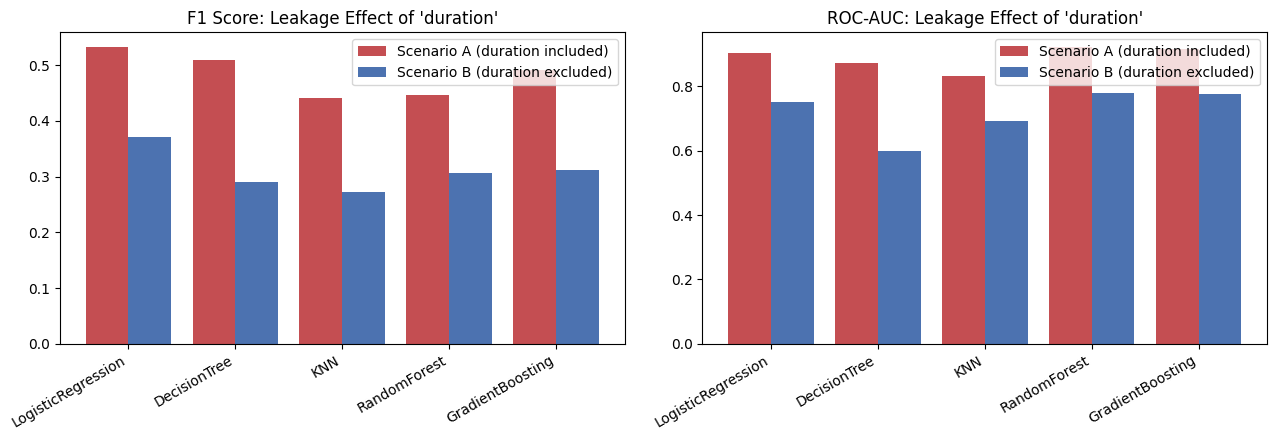

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(compare))

# F1 comparison
axes[0].bar(x - 0.2, compare["F1_A"], width=0.4, label="Scenario A (duration included)", color="#C44E52")
axes[0].bar(x + 0.2, compare["F1_B"], width=0.4, label="Scenario B (duration excluded)", color="#4C72B0")
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare["Model"], rotation=30, ha="right")
axes[0].set_title("F1 Score: Leakage Effect of 'duration'")
axes[0].legend()

# ROC-AUC comparison
axes[1].bar(x - 0.2, compare["ROC-AUC_A"], width=0.4, label="Scenario A (duration included)", color="#C44E52")
axes[1].bar(x + 0.2, compare["ROC-AUC_B"], width=0.4, label="Scenario B (duration excluded)", color="#4C72B0")
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare["Model"], rotation=30, ha="right")
axes[1].set_title("ROC-AUC: Leakage Effect of 'duration'")
axes[1].legend()

plt.tight_layout()
plt.show()

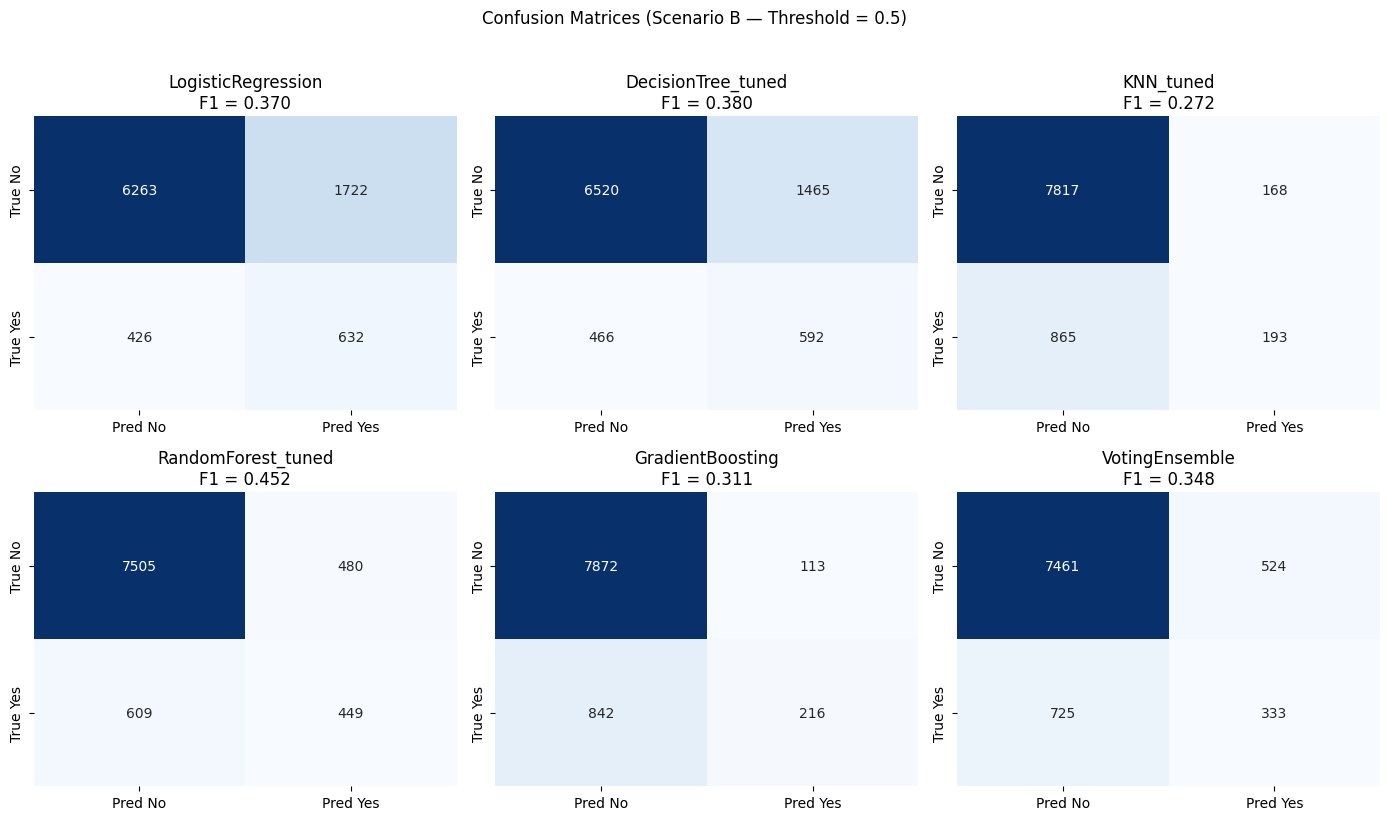

In [100]:
selected_models = ["LogisticRegression", "DecisionTree_tuned", "KNN_tuned", "RandomForest_tuned", "GradientBoosting", "VotingEnsemble"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, name in zip(axes.ravel(), selected_models):
    cm = confusion_matrix(y_test, (proba_store[name] >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred No", "Pred Yes"], yticklabels=["True No", "True Yes"])
    ax.set_title(f"{name}\nF1 = {f1_score(y_test, (proba_store[name] >= 0.5).astype(int)):.3f}")

plt.suptitle("Confusion Matrices (Scenario B — Threshold = 0.5)", y=1.02)
plt.tight_layout()
plt.show()

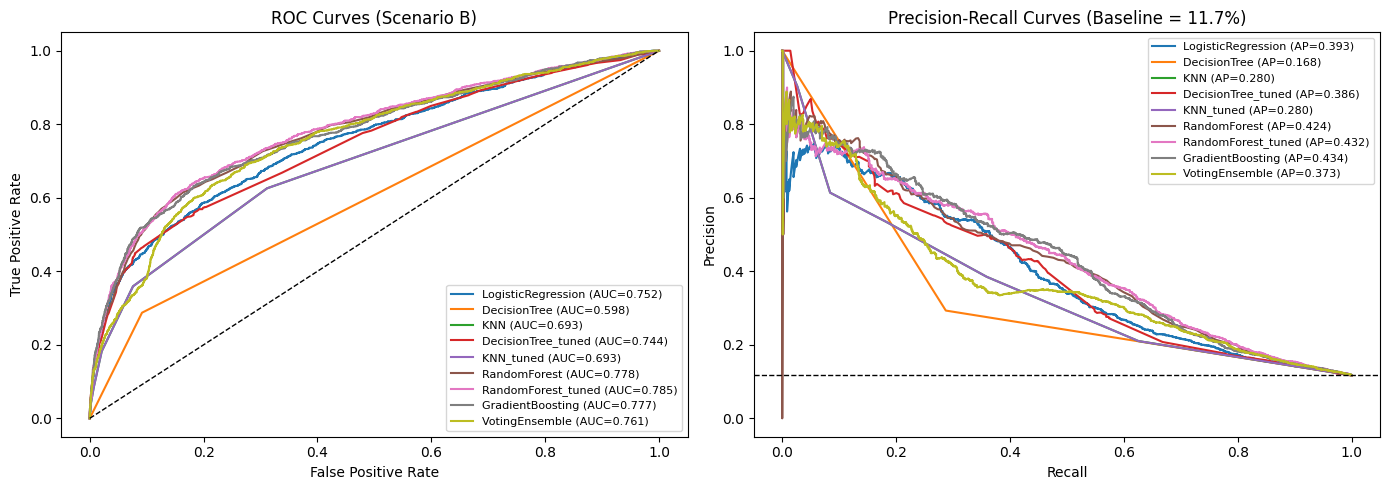

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in proba_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=1.5, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=1.5, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Scenario B)")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline(y_test.mean(), color="k", linestyle="--", lw=1)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Baseline = 11.7%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Cumulative Gains & Lift Table (Best Model: GradientBoosting):
 Top %  Clients Called  Subscribers Found  % of All Subscribers Captured  Conversion Rate %  Lift
    10             904                448                           42.3               49.6  4.24
    20            1808                613                           57.9               33.9  2.90
    30            2712                724                           68.4               26.7  2.28
    40            3617                791                           74.8               21.9  1.87
    50            4521                839                           79.3               18.6  1.59
    60            5425                901                           85.2               16.6  1.42
    70            6330                945                           89.3               14.9  1.28
    80            7234                993                           93.9               13.7  1.17
    90            8138               1031               

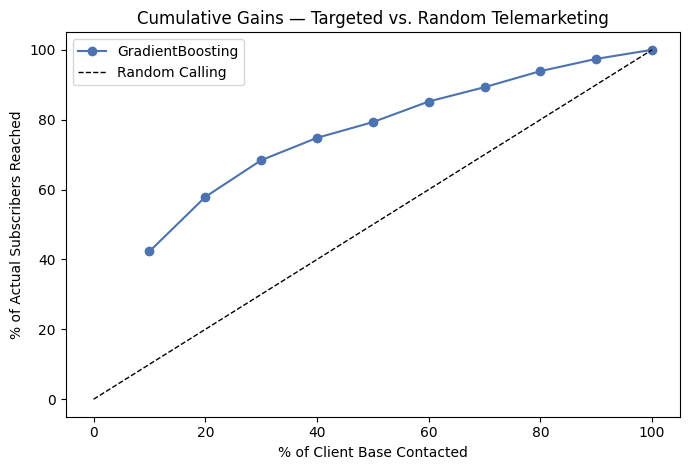

In [126]:
best_model_name = thr_df.iloc[0]["Model"]
best_proba = proba_store[best_model_name]

# Sort test clients by predicted probability in descending order
order = np.argsort(-best_proba)
y_sorted = y_test.iloc[order].values

deciles = []
n = len(y_sorted)

for d in range(1, 11):
    top = y_sorted[: int(n * d / 10)]
    deciles.append({
        "Top %": d * 10,
        "Clients Called": len(top),
        "Subscribers Found": int(top.sum()),
        "% of All Subscribers Captured": round(100 * top.sum() / y_test.sum(), 1),
        "Conversion Rate %": round(100 * top.mean(), 1),
        "Lift": round(top.mean() / y_test.mean(), 2)
    })

lift_df = pd.DataFrame(deciles)
print(f"Cumulative Gains & Lift Table (Best Model: {best_model_name}):")
print(lift_df.to_string(index=False))

# Plot cumulative gains curve
plt.figure(figsize=(7, 4.8))
plt.plot(lift_df["Top %"], lift_df["% of All Subscribers Captured"], marker="o", label=best_model_name, color="#4C72B0")
plt.plot([0, 100], [0, 100], "k--", lw=1, label="Random Calling")
plt.xlabel("% of Client Base Contacted")
plt.ylabel("% of Actual Subscribers Reached")
plt.title("Cumulative Gains — Targeted vs. Random Telemarketing")
plt.legend()
plt.tight_layout()
plt.show()

In [127]:
best_thresh = thr_df.iloc[0]["Best Threshold"]
final_preds = (best_proba >= best_thresh).astype(int)

print(f"Classification Report for {best_model_name} (Optimized Threshold = {best_thresh}):\n")
print(classification_report(y_test, final_preds, target_names=["No", "Yes"], digits=3))

Classification Report for GradientBoosting (Optimized Threshold = 0.174):

              precision    recall  f1-score   support

          No      0.931     0.925     0.928      7985
         Yes      0.463     0.485     0.474      1058

    accuracy                          0.874      9043
   macro avg      0.697     0.705     0.701      9043
weighted avg      0.877     0.874     0.875      9043

